In [ ]:
# Mount Google Drive to access your data
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading 14 GNV1B file(s)...
  Loading cached ECI transform: /content/drive/MyDrive/science_fair/GRACEFO_Nov2025/_eci_cache_1209600.npz
  1209600 samples | arc 14.00 days
  loaded 'inverse PINN': 20000 samples, mean Ft=-3.069e-07 m/s^2
  loaded 'Neural ODE': 20000 samples, mean Ft=+1.133e-11 m/s^2

Propagating 12 windows x 24 h x 3 configurations...
  window 12/12 done

POSITION RMS ERROR vs PROPAGATION TIME  (metres, averaged over windows)
  configuration                1 h         3 h         6 h        12 h        24 h
  --------------------------------------------------------------------------------
  gravity only               1,112       3,328       5,567       7,720      14,942
  inverse PINN               1,113       3,337       5,619       7,911      14,577
  Neural ODE                 1,111       3,324       5,560       7,711      14,926

INTERPRETATION
  Gravity-only baseline at 24 h: 14,942 m

  A model improves if it lowers the error RELATIVE to that baseline.
  Per-window 

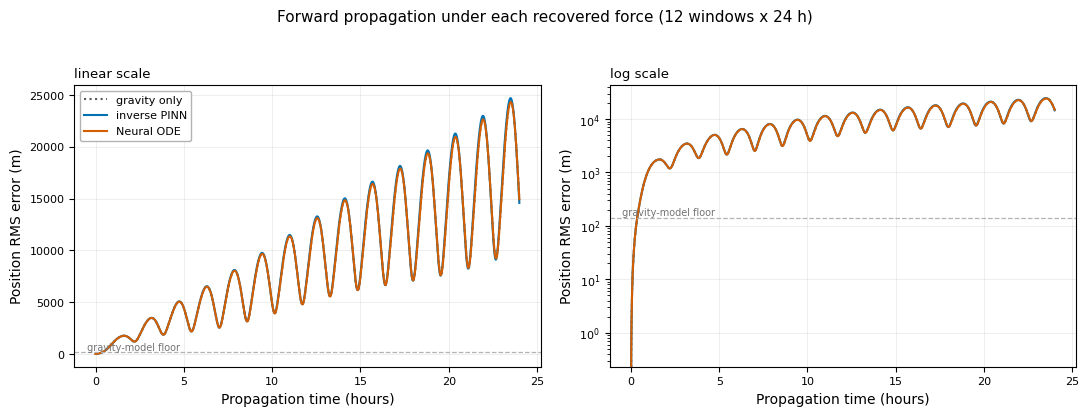

In [ ]:
"""
propagation_comparison.py

Test of whether each recovered nongravitational force
actually reproduces the observed orbit

WHY THIS EXISTS

The two models' internal training losses are not comparable. The Neural ODE
reports a windowed state MSE measured from a true initial condition, while the
inverse PINN reports a trajectory-network fit. Quoting them side by
side (545 m vs 30,193 m) compares different quantities and does not measure
"trajectory reconstruction accuracy" in the sense that we might assume.

This script applies one procedure to both models:

    integrate   dr/dt = v ,   dv/dt = a_gravity(r) + F_model(t)

from a measured initial state, then compare the propagated position to the
measured GNV1B position. A physically correct force should lower the
position error compared to propagating under gravity alone. A force that
only fitted short windows should not, and may even do worse over long spans.

Gravity-only propagation is the baseline, or control, and whatever it achieves
is what the force has to beat to be doing the true work.
CHOICE OF WINDOW LENGTH

Residual gravity mismodeling (J2-J5 versus EGM2008 degree 60, ~1.77e-4
m/s^2) is largely oscillatory, so its displacement is bounded at roughly
a/omega^2 ~ 142 m. Drag is secular and grows as 0.5*a*t^2:

    window    iPINN 3.07e-7      NODE 1.10e-7
      2 h            8 m               3 m     <- gravity-limited, not useful
     12 h          286 m             103 m
     24 h        1,146 m             411 m     <- force-limited, informative

Windows shorter than ~12 h cant discriminate because the gravity error
surpasses the force effect. WINDOW_HOURS = 24 gives roughly 8x separation.
This is why the comparison is run over day-long arcs rather than the short
windows either model trained on.

FRAME NOTE

Each model's force is stored in RTN. During propagation it is converted to
ECI using the PROPAGATED state's r and v, not the measured ones, so the
force stays tied to the instantaneous orbit geometry as it would in a real
propagator.
"""

import os
import math
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from astropy.utils import iers
iers.conf.auto_download = False
iers.conf.auto_max_age = None
from astropy.time import Time
from astropy.coordinates import (
    ITRS, GCRS, CartesianDifferential, CartesianRepresentation)
import astropy.units as u


class CFG:
    DATA_FOLDER   = "data"
    GNV1B_PATTERN = "GNV1B_2025-11-*_C_04.txt"
    SKIP_ROWS     = 148
    COLUMNS       = [0, 3, 4, 5, 9, 10, 11]

    MODELS = {                      # label -> saved-array prefix
        'inverse PINN': 'v7_full',
        'Neural ODE':   'node_v2',
    }

    WINDOW_HOURS = 24.0             # see module docstring
    N_WINDOWS    = 12               # spread over the arc
    EVAL_DT      = 60.0             # comparison cadence within a window

    MU  = 3.986004418e14
    R_E = 6378137.0
    J2, J3, J4, J5 = 1.08262668e-3, -2.53265649e-6, -1.61962159e-6, -2.27296083e-7

    RTOL, ATOL = 1e-10, 1e-6        # SI units: atol in metres / (m/s)



# DATA

def load_gnv1b():
    pattern = os.path.join(CFG.DATA_FOLDER, CFG.GNV1B_PATTERN)
    files = sorted(glob(pattern))
    if not files:
        # Distinguish the ways this fails: wrong folder, or a pattern that
        # matches nothing in a folder that does exist.
        msg = [f"No GNV1B files matching:\n  {pattern}"]
        if not os.path.isdir(CFG.DATA_FOLDER):
            msg.append(f"\nThe data folder does not exist:\n  {CFG.DATA_FOLDER}\n"
                       f"Create it and place the PO.DAAC GNV1B files inside, or "
                       f"update CFG.DATA_FOLDER.")
        else:
            names = sorted(os.listdir(CFG.DATA_FOLDER))
            gnv = [n for n in names if n.startswith('GNV1B')]
            msg.append(f"\nFolder exists with {len(names)} entries, "
                       f"{len(gnv)} starting with 'GNV1B'.")
            msg.append(f"Sample: {names[:8]}")
            if gnv:
                msg.append(f"GNV1B present: {gnv[:4]} -- adjust CFG.GNV1B_PATTERN "
                           f"to match these filenames.")
        raise FileNotFoundError("\n".join(msg))
    print(f"Loading {len(files)} GNV1B file(s)...")
    frames = []
    for f in files:
        df = pd.read_csv(f, skiprows=CFG.SKIP_ROWS, sep=r'\s+', header=None,
                         usecols=CFG.COLUMNS, dtype=np.float64, engine='python')
        frames.append(df.values)
    raw = np.concatenate(frames, axis=0)
    raw = raw[np.argsort(raw[:, 0])]
    _, uniq = np.unique(raw[:, 0], return_index=True)
    raw = raw[uniq]

    t_gps, r_ecef, v_ecef = raw[:, 0], raw[:, 1:4], raw[:, 4:7]
    cache = os.path.join(CFG.DATA_FOLDER, f'_eci_cache_{len(t_gps)}.npz')
    if os.path.exists(cache):
        print(f"  Loading cached ECI transform: {cache}")
        c = np.load(cache)
        r_eci, v_eci = c['r_eci'], c['v_eci']
    else:
        print("  ECEF->ECI (astropy)...")
        times = Time(t_gps[0], format='gps', scale='utc') + (t_gps - t_gps[0]) * u.s
        rep = CartesianRepresentation(r_ecef[:, 0]*u.m, r_ecef[:, 1]*u.m, r_ecef[:, 2]*u.m)
        dif = CartesianDifferential(v_ecef[:, 0]*u.m/u.s, v_ecef[:, 1]*u.m/u.s,
                                    v_ecef[:, 2]*u.m/u.s)
        g = ITRS(rep.with_differentials({'s': dif}), obstime=times).transform_to(
            GCRS(obstime=times))
        r_eci = g.cartesian.xyz.to(u.m).value.T
        v_eci = g.cartesian.differentials['s'].d_xyz.to(u.m/u.s).value.T
        np.savez(cache, r_eci=r_eci, v_eci=v_eci)
    print(f"  {len(t_gps)} samples | arc {(t_gps[-1]-t_gps[0])/86400:.2f} days")
    return t_gps, r_eci, v_eci


def load_model_force(prefix):
    """-> (t_seconds_since_arc_start, Fr, Ft, Fn) or None if absent."""
    def p(name):
        return os.path.join(CFG.DATA_FOLDER, f'{prefix}_{name}.npy')
    if not all(os.path.exists(p(n)) for n in ('time', 'Fr', 'Ft', 'Fn')):
        return None
    t_hr = np.load(p('time'))            # both models save hours since arc start
    return (t_hr * 3600.0, np.load(p('Fr')), np.load(p('Ft')), np.load(p('Fn')))



# DYNAMICS

def gravity_j2_to_j5(r):
    """Dimensional J2-J5 (m/s^2). Same field both models carried internally,
    so gravity fidelity is common to every curve in the comparison."""
    x, y, z = r[0], r[1], r[2]
    rr = math.sqrt(x*x + y*y + z*z)
    r2, r4 = rr*rr, rr**4
    z2 = z*z; z4 = z2*z2; rxy2 = x*x + y*y
    mu, Re = CFG.MU, CFG.R_E

    a = np.array([-mu*x/rr**3, -mu*y/rr**3, -mu*z/rr**3])
    c2 = 1.5*CFG.J2*mu*Re**2/rr**5
    a += c2*np.array([x*(5*z2/r2-1), y*(5*z2/r2-1), z*(5*z2/r2-3)])
    k3 = mu*CFG.J3*Re**3/rr**7*2.5
    a += np.array([k3*x*z*(7*z2/r2-3), k3*y*z*(7*z2/r2-3),
                   k3*(6*z2*rxy2/r2 - 3*rxy2 - 6*z4/r2 + 3*z2)])
    k4 = mu*CFG.J4*Re**4/rr**7*(5.0/8.0)
    a += np.array([k4*x*(3-42*z2/r2+63*z4/r4), k4*y*(3-42*z2/r2+63*z4/r4),
                   k4*z*(15-70*z2/r2+63*z4/r4)])
    k5 = mu*CFG.J5*Re**5/rr**9*(3.0/8.0)
    a += np.array([k5*x*z*(35-210*z2/r2+231*z4/r4),
                   k5*y*z*(35-210*z2/r2+231*z4/r4),
                   k5*((15.0/8.0)*rxy2*z*(7-21*z2/r2)
                       - (3.0/8.0)*z*(35*z4/r4-30*z2/r2+3)*r2)/r2])
    return a


def rtn_to_eci(F_rtn, r, v):
    R_hat = r / np.linalg.norm(r)
    N = np.cross(r, v); N_hat = N / np.linalg.norm(N)
    T_hat = np.cross(N_hat, R_hat)
    return F_rtn[0]*R_hat + F_rtn[1]*T_hat + F_rtn[2]*N_hat


def propagate(r0, v0, t_eval, t0_abs, force=None):
    """Integrate from (r0,v0) over t_eval (seconds since arc start).
    `force` is (t_s, Fr, Ft, Fn) interpolated in time, applied in RTN using
    the propagated state's own geometry. Returns positions (n,3) or None."""
    def rhs(t, y):
        r, v = y[:3], y[3:]
        a = gravity_j2_to_j5(r)
        if force is not None:
            ts, Fr, Ft, Fn = force
            f = np.array([np.interp(t, ts, Fr), np.interp(t, ts, Ft),
                          np.interp(t, ts, Fn)])
            a = a + rtn_to_eci(f, r, v)
        return np.concatenate([v, a])

    sol = solve_ivp(rhs, (t_eval[0], t_eval[-1]), np.concatenate([r0, v0]),
                    t_eval=t_eval, method='DOP853',
                    rtol=CFG.RTOL, atol=CFG.ATOL)
    if not sol.success or sol.y.shape[1] != len(t_eval):
        return None
    return sol.y[:3, :].T



# MAIN

def main():
    t_gps, r_eci, v_eci = load_gnv1b()
    t_rel = t_gps - t_gps[0]

    forces = {}
    for label, prefix in CFG.MODELS.items():
        f = load_model_force(prefix)
        if f is None:
            print(f"  WARNING: no saved arrays for '{label}' (prefix {prefix}_) -- skipped")
        else:
            print(f"  loaded '{label}': {len(f[0])} samples, "
                  f"mean Ft={f[2].mean():+.3e} m/s^2")
            forces[label] = f
    if not forces:
        raise SystemExit("No model forces found. Run the models first.")

    win_s = CFG.WINDOW_HOURS * 3600.0
    starts = np.linspace(0, t_rel[-1] - win_s, CFG.N_WINDOWS)
    n_eval = int(win_s / CFG.EVAL_DT) + 1

    curves = {k: [] for k in ['gravity only'] + list(forces)}
    print(f"\nPropagating {CFG.N_WINDOWS} windows x {CFG.WINDOW_HOURS:.0f} h "
          f"x {1+len(forces)} configurations...")

    for wi, s in enumerate(starts):
        i0 = int(np.searchsorted(t_rel, s))
        t_eval = t_rel[i0] + np.arange(n_eval) * CFG.EVAL_DT
        if t_eval[-1] > t_rel[-1]:
            continue
        idx = np.searchsorted(t_rel, t_eval)
        idx = np.clip(idx, 0, len(t_rel) - 1)
        r_true = r_eci[idx]
        r0, v0 = r_eci[i0], v_eci[i0]

        for label in curves:
            f = None if label == 'gravity only' else forces[label]
            r_prop = propagate(r0, v0, t_eval, t_rel[i0], force=f)
            if r_prop is None:
                continue
            curves[label].append(np.linalg.norm(r_prop - r_true, axis=1))
        print(f"  window {wi+1}/{CFG.N_WINDOWS} done", end='\r')

    print("\n")
    elapsed_hr = np.arange(n_eval) * CFG.EVAL_DT / 3600.0
    per_window = {k: np.vstack(v) for k, v in curves.items() if v}
    stats = {k: np.sqrt(np.mean(v**2, axis=0)) for k, v in per_window.items()}

    # table
    marks = [1, 3, 6, 12, 24]
    marks = [m for m in marks if m <= CFG.WINDOW_HOURS]
    print("=" * 78)
    print("POSITION RMS ERROR vs PROPAGATION TIME  (metres, averaged over windows)")
    print("=" * 78)
    hdr = "  " + f"{'configuration':<20}" + "".join(f"{m:>10.0f} h" for m in marks)
    print(hdr); print("  " + "-" * (len(hdr) - 2))
    for k, v in stats.items():
        row = "  " + f"{k:<20}"
        for m in marks:
            row += f"{v[np.argmin(np.abs(elapsed_hr - m))]:>12,.0f}"
        print(row)

    # verdict
    print("\n" + "=" * 78)
    print("INTERPRETATION")
    print("=" * 78)
    base = stats.get('gravity only')
    base_w = per_window.get('gravity only')
    if base is not None:
        end = -1
        print(f"  Gravity-only baseline at {CFG.WINDOW_HOURS:.0f} h: {base[end]:,.0f} m")
        print()
        print("  A model improves if it lowers the error RELATIVE to that baseline.")
        print("  Per-window agreement matters more than the mean: a real effect")
        print("  should help in most windows, not average out of a few large ones.")
        print()
        for k, v in stats.items():
            if k == 'gravity only':
                continue
            impr = (base[end] - v[end]) / base[end] * 100
            # per-window: how often, and how consistently, does it help?
            pw = (base_w[:, end] - per_window[k][:, end]) / base_w[:, end] * 100
            wins = int((pw > 0).sum())
            print(f"  {k:<16}: {v[end]:>9,.0f} m   {impr:+6.2f}% vs baseline")
            print(f"  {'':<16}  per-window {pw.mean():+6.2f}% +/- {pw.std():.2f}%   "
                  f"improved in {wins}/{len(pw)} windows")

        print()
        print("  CAVEAT -- THIS TEST IS GRAVITY-LIMITED, NOT FORCE-LIMITED.")
        print("  The propagator uses J2-J5. Gravity mismodeling perturbs the")
        print("  semi-major axis, hence the orbital period, so along-track error")
        print("  drifts SECULARLY rather than staying bounded. That is why the")
        print("  gravity-only baseline reaches ~15 km at 24 h. Drag's own")
        print("  along-track drift over the same span is ~3.4 km (from")
        print("  da/dt = 2*a_T/n), i.e. roughly 4x SMALLER than the error it")
        print("  has to show through. Percentage improvements of a few percent")
        print("  are therefore the most this configuration can resolve, and an")
        print("  apparent 'no improvement' does not establish that a force is")
        print("  wrong. To make the test force-limited, propagate with the same")
        print("  degree-60 field the anchor uses.")

    # plot
    plt.style.use('default')
    colours = {'gravity only': '0.35', 'inverse PINN': '#0072B2',
               'Neural ODE': '#D55E00'}
    styles  = {'gravity only': ':'}
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    fig.patch.set_facecolor('white')

    for a, logy in zip(ax, (False, True)):
        for k, v in stats.items():
            a.plot(elapsed_hr, v, color=colours.get(k, 'k'),
                   ls=styles.get(k, '-'), lw=1.5, label=k)
        a.axhline(142, color='0.7', lw=0.9, ls='--')
        a.text(0.02, 142, ' gravity-model floor', color='0.45', fontsize=7,
               va='bottom', transform=a.get_yaxis_transform())
        a.set_xlabel('Propagation time (hours)')
        a.set_ylabel('Position RMS error (m)')
        a.grid(alpha=0.3, lw=0.5); a.tick_params(labelsize=8)
        for sp in a.spines.values():
            sp.set_linewidth(0.8)
        if logy:
            a.set_yscale('log'); a.set_title('log scale', fontsize=9.5, loc='left')
        else:
            a.set_title('linear scale', fontsize=9.5, loc='left')
            a.legend(fontsize=8, framealpha=1.0, edgecolor='0.7')

    fig.suptitle('Forward propagation under each recovered force '
                 f'({CFG.N_WINDOWS} windows x {CFG.WINDOW_HOURS:.0f} h)',
                 fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    out = os.path.join(CFG.DATA_FOLDER, 'propagation_comparison.png')
    fig.savefig(out, dpi=300, facecolor='white', bbox_inches='tight')
    print(f"\nSaved plot: {out}")

    np.savez(os.path.join(CFG.DATA_FOLDER, 'propagation_comparison.npz'),
             elapsed_hr=elapsed_hr, **{k.replace(' ', '_'): v for k, v in stats.items()})
    print("Saved: propagation_comparison.npz")


if __name__ == '__main__':
    main()